In [1]:
%load_ext autoreload
%autoreload 2

import copy, csv, gzip, os, re, sys, subprocess, json
import contextlib, random, glob, shutil, warnings, math
from math import ceil
import gzip, random
from collections import defaultdict


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from scipy.optimize import minimize, curve_fit
from math import ceil, sqrt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import ScalarFormatter

from Bio.SeqIO.QualityIO import FastqGeneralIterator
from Bio.Seq import Seq
from Bio import SeqIO


In [2]:
%%bash
ls

pulldown_param.ipynb
target_enrichment_mismatches.csv
target_enrichment_mismatches.png


# Parametrization of TES pull-down
The goal here is to take a small data snippet from Twist and use it to parametrize a pull-down probability function.

In [3]:
# Read in the Twist (digitized) data:
df_mm = pd.read_csv("target_enrichment_mismatches.csv")
df_mm

,Mismatches,Contigious,Random
0,0,1.00000,1.00000
1,2,0.99986,0.96296
2,4,0.97072,0.89465
3,6,0.92772,0.81297
4,10,0.88509,0.52820
5,15,0.80683,0.19868
6,20,0.74669,0.04419
7,30,NaN,0.00323
8,31,0.59733,NaN
9,50,0.34058,0.00000


In [4]:
### Curve fitting functions ###


# -------------------------
# Model definitions
# -------------------------
def f_linear(x, a, b):
    pred = a*x + b
    pred[pred > 1] = 1
    pred[pred < 0] = 0
    return pred


def f_quad(x, a, b, c):
    pred = a*x**2 + b*x + c
    pred[pred < 0] = 0
    return pred

def f_cubic(x, a, b, c, d):
    pred = a*x**3 + b*x**2 + c*x + d
    pred[pred < 0] = 0
    return pred

def f_exp(x, a, b, c):
    pred = a*np.exp(b*x) + c
    pred[pred < 0] = 0
    return pred

def f_power(x, a, b, c):
    pred = a*np.power(x, b) + c  # requires x>0
    pred[pred < 0] = 0
    return pred

def f_log(x, a, b):
    pred = a*np.log(x) + b       # requires x>0
    pred[pred < 0] = 0
    return pred

def f_sigmoid(x, k, x0, c):
    # Logistic/sigmoid with baseline c and amplitude L
    # y = L / (1 + exp(-k*(x - x0))) + c
    pred = 1.0 / (c + np.exp(-k * (x - x0)))
    pred[pred < 0] = 0
    return pred

MODELS = {
    "Linear": {
        "func": f_linear, "n_params": 2,
        "domain_ok": lambda x, y: np.isfinite(x).all() and np.isfinite(y).all(),
        "p0": lambda x, y: np.polyfit(x, y, 1)[::-1] if x.size >= 2 else np.array([1.0, 0.0]),
        "reorder_p0": lambda p: np.array([p[1], p[0]])  # [b,a] -> [a,b]
    },
    "Quadratic": {
        "func": f_quad, "n_params": 3,
        "domain_ok": lambda x, y: np.isfinite(x).all() and np.isfinite(y).all(),
        "p0": lambda x, y: np.polyfit(x, y, 2)[::-1] if x.size >= 3 else np.array([0.0, 1.0, 0.0]),
        "reorder_p0": lambda p: np.array([p[2], p[1], p[0]])  # reverse
    },
    "Cubic": {
        "func": f_cubic, "n_params": 4,
        "domain_ok": lambda x, y: np.isfinite(x).all() and np.isfinite(y).all(),
        "p0": lambda x, y: np.polyfit(x, y, 3)[::-1] if x.size >= 4 else np.array([0.0, 0.0, 1.0, 0.0]),
        "reorder_p0": lambda p: np.array([p[3], p[2], p[1], p[0]])
    },
    "Exponential (a*exp(bx)+c)": {
        "func": f_exp, "n_params": 3,
        "domain_ok": lambda x, y: np.isfinite(x).all() and np.isfinite(y).all(),
        "p0": None, "reorder_p0": None
    },
    "Power (a*x^b + c)": {
        "func": f_power, "n_params": 3,
        "domain_ok": lambda x, y: np.all(x > 0) and np.isfinite(x).all() and np.isfinite(y).all(),
        "p0": None, "reorder_p0": None
    },
    "Logarithmic (a*log(x)+b)": {
        "func": f_log, "n_params": 2,
        "domain_ok": lambda x, y: np.all(x > 0) and np.isfinite(x).all() and np.isfinite(y).all(),
        "p0": None, "reorder_p0": None
    },
    "Sigmoid (1/(c+exp(-k*(x-x0))))": {
        "func": f_sigmoid, "n_params": 3,
        "domain_ok": lambda x, y: np.isfinite(x).all() and np.isfinite(y).all(),  # no special domain
        "p0": None, "reorder_p0": None
    },
}

# -------------------------
# Utilities
# -------------------------
def sanitize_xy(x, y):
    x = np.asarray(x, dtype=float).ravel()
    y = np.asarray(y, dtype=float).ravel()
    mask = np.isfinite(x) & np.isfinite(y)
    return x[mask], y[mask]

def initial_guess(model_name, x, y):
    spec = MODELS[model_name]
    if model_name == "Exponential (a*exp(bx)+c)":
        y_min = np.min(y); eps = 1e-6
        c0 = y_min - eps
        yy = y - c0
        pos = yy > 0
        if pos.sum() >= 2:
            xb = x[pos]
            lb = np.log(yy[pos])
            A = np.vstack([xb, np.ones_like(xb)]).T
            b_est, alpha = np.linalg.lstsq(A, lb, rcond=None)[0]
            a0 = np.exp(alpha)
            return np.array([a0, b_est, c0])
        else:
            return np.array([1.0, 0.1, c0])
    elif model_name == "Power (a*x^b + c)":
        c0 = 0.0
        pos = (x > 0) & (y - c0 > 0)
        if pos.sum() >= 2:
            lx = np.log(x[pos]); ly = np.log(y[pos] - c0)
            A = np.vstack([lx, np.ones_like(lx)]).T
            b_est, alpha = np.linalg.lstsq(A, ly, rcond=None)[0]
            a0 = np.exp(alpha)
            return np.array([a0, b_est, c0])
        else:
            return np.array([1.0, 1.0, 0.0])
    elif model_name == "Logarithmic (a*log(x)+b)":
        lx = np.log(x)
        A = np.vstack([lx, np.ones_like(lx)]).T
        a_est, b_est = np.linalg.lstsq(A, y, rcond=None)[0]
        return np.array([a_est, b_est])
    elif model_name == "Sigmoid (1/(c+exp(-k*(x-x0))))":
        # Heuristic:
        #   c ~ min(y), L ~ max(y)-min(y)
        #   Use logit to estimate k and x0: log((y-c)/(L) / (1 - (y-c)/L)) ≈ k*x - k*x0
        y_min, y_max = np.min(y), np.max(y)
        L0 = max(y_max - y_min, 1e-6)
        c0 = 1
        s = (y - c0) / L0
        eps = 1e-6
        s = np.clip(s, eps, 1 - eps)
        logit = np.log(s / (1 - s))
        # Linear regression: logit ≈ k*x + b, then x0 ≈ -b/k
        A = np.vstack([x, np.ones_like(x)]).T
        try:
            k_est, b_est = np.linalg.lstsq(A, logit, rcond=None)[0]
            if abs(k_est) < 1e-8:
                # fallbacks if slope ~ 0
                xr = np.percentile(x, 97.5) - np.percentile(x, 2.5)
                k_est = 1.0 / max(xr, 1.0)
            x0_est = -b_est / k_est
        except Exception:
            # Robust fallback
            x0_est = np.median(x)
            xr = np.percentile(x, 97.5) - np.percentile(x, 2.5)
            k_est = 1.0 / max(xr, 1.0)
        return np.array([k_est, x0_est, c0])
    else:
        p0_func = spec.get("p0", None)
        if p0_func is not None:
            p0_raw = p0_func(x, y)
            reorder = spec.get("reorder_p0", None)
            return reorder(p0_raw) if reorder is not None else np.array(p0_raw)
        return np.zeros(spec["n_params"], dtype=float)

def fit_with_L1(x, y, func, p0):
    # Objective: sum |residuals|
    def obj(p):
        return np.sum(np.abs(func(x, *p) - y))
    best = None
    for method in ("Powell", "Nelder-Mead"):
        for scale in (1.0, 0.5, 2.0):
            p_start = p0 * scale
            try:
                res = minimize(obj, p_start, method=method,
                               options=dict(maxiter=10000, xatol=1e-8, fatol=1e-8, disp=False))
                if (best is None) or (res.fun < best.fun):
                    best = res
            except Exception:
                pass
    if best is not None and best.success:
        params = best.x
        l1 = best.fun
        return params, l1
    # fallback
    try:
        popt, _ = curve_fit(lambda t, *p: func(t, *p), x, y, p0=p0, maxfev=20000)
        l1 = np.sum(np.abs(func(x, *popt) - y))
        return popt, l1
    except Exception:
        return p0, np.sum(np.abs(func(x, *p0) - y))

def aic_laplace(L1, n, k, eps=1e-12):
    # AIC for Laplace errors given L1 = sum |residuals|
    L1_safe = max(L1, eps)
    return 2*k + 2*n*np.log(2*L1_safe/n) + 2*n

def aicc_correction(aic, n, k):
    # AICc = AIC + 2k(k+1)/(n-k-1)
    denom = (n - k - 1)
    if denom <= 0:
        return np.inf
    return aic + (2*k*(k+1))/denom

# -------------------------
# Formula formatting (3 sig figs)
# -------------------------
def _fmt_sig(x, sig=3):
    s = f"{float(x):.{sig}g}"
    # Clean -0
    if s in ("-0", "-0.0"):
        s = "0"
    return s
def formula_string(name, params, sig=3):
    # Build a LaTeX math formula string y = ...
    p = list(params)
    if name == "Linear":
        a, b = p
        return rf"$y = { _fmt_sig(a,sig) }\,x \;+\; { _fmt_sig(b,sig) }$"
    elif name == "Quadratic":
        a, b, c = p
        return rf"$y = { _fmt_sig(a,sig) }\,x^2 \;+\; { _fmt_sig(b,sig) }\,x \;+\; { _fmt_sig(c,sig) }$"
    elif name == "Cubic":
        a, b, c, d = p
        return rf"$y = { _fmt_sig(a,sig) }\,x^3 \;+\; { _fmt_sig(b,sig) }\,x^2 \;+\; { _fmt_sig(c,sig) }\,x \;+\; { _fmt_sig(d,sig) }$"
    elif "Exponential" in name:
        a, b, c = p
        return rf"$y = { _fmt_sig(a,sig) }\,e^{{{ _fmt_sig(b,sig) }\,x}} \;+\; { _fmt_sig(c,sig) }$"
    elif "Power" in name:
        a, b, c = p
        return rf"$y = { _fmt_sig(a,sig) }\,x^{{{ _fmt_sig(b,sig) }}} \;+\; { _fmt_sig(c,sig) }$"
    elif "Logarithmic" in name:
        a, b = p
        return rf"$y = { _fmt_sig(a,sig) }\,\log(x) \;+\; { _fmt_sig(b,sig) }$"
    elif "Sigmoid" in name:
        k, x0, c = p
        return rf"$y = \dfrac{{{_fmt_sig(1.0,sig)}}}{{{_fmt_sig(c,sig)} + e^{{-{_fmt_sig(k,sig)}\,(x - {_fmt_sig(x0,sig)})}}}}$"
    else:
        # Fallback: generic parameter list
        ps = ", ".join(_fmt_sig(v, sig) for v in p)
        return rf"$\text{{params}} = [{ps}]$"

# -------------------------
# Main function
# -------------------------
def evaluate_and_plot(x, y, models_to_try=None, points_for_curve=500, figsize=(14, 10),
                      use_aicc=False, sig_figs=3):
    x, y = sanitize_xy(x, y)
    n = x.size
    if n < 2:
        raise ValueError("Need at least 2 finite points in x and y.")

    if models_to_try is None:
        models_to_try = list(MODELS.keys())

    results = []
    for name in models_to_try:
        spec = MODELS[name]
        func = spec["func"]
        k = spec["n_params"]

        if not spec["domain_ok"](x, y):
            print(f"Skipping '{name}' due to domain constraints.")
            continue
        p0 = initial_guess(name, x, y)
        params, l1 = fit_with_L1(x, y, func, p0)
        yhat = func(x, *params)
        mae = np.mean(np.abs(yhat - y))
        aic = aic_laplace(l1, n, k)
        aic_used = aicc_correction(aic, n, k) if use_aicc else aic

        results.append({
            "model": name, "func": func, "params": np.asarray(params),
            "l1": float(l1), "mae": float(mae),
            "aic": float(aic), "aic_used": float(aic_used), "k": k, "n": n
        })

    if not results:
        raise RuntimeError("No models could be fit (domain constraints or data issues).")

    # Rank by AIC (or AICc if selected)
    results_sorted = sorted(results, key=lambda r: r["aic_used"])
    best = results_sorted[0]

    # ΔAIC and Akaike weights
    aic_min = best["aic_used"]
    deltas = np.array([r["aic_used"] - aic_min for r in results_sorted])
    weights = np.exp(-0.5 * deltas)
    weights = weights / weights.sum()
    for r, d, w in zip(results_sorted, deltas, weights):
        r["delta_aic"] = float(d)
        r["akaike_weight"] = float(w)

    # --------------- Plot: individual fits ---------------
    n_models = len(results_sorted)
    ncols = min(3, n_models)
    nrows = int(ceil(n_models / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, constrained_layout=True)
    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = np.array([axes])
    axes = axes.reshape(nrows, ncols)

    xmin, xmax = float(np.min(x)), float(np.max(x))
    grid_default = np.linspace(xmin, xmax, points_for_curve)
    grid_pos = None
    if xmax > 0:
        grid_pos = np.linspace(max(xmin, np.nextafter(0.0, 1.0)), xmax, points_for_curve)

    for i, res in enumerate(results_sorted):
        r, c = divmod(i, ncols)
        ax = axes[r, c]
        func = res["func"]
        name = res["model"]
        params = res["params"]

        xcurve = grid_pos if (("Power" in name) or ("Logarithmic" in name)) else grid_default

        # scatter + fit
        ax.scatter(x, y, s=16, alpha=0.7, label="data", color="#333333")
        try:
            ycurve = func(xcurve, *params)
            ax.plot(xcurve, ycurve, lw=2, color="#1f77b4", label="fit")
        except Exception:
            pass

        # Title with AIC info
        aic_label = "AICc" if use_aicc else "AIC"
        info = f"{aic_label}={res['aic_used']:.3f} | Δ={res['delta_aic']:.3f} | w={res['akaike_weight']:.2f} | L1={res['l1']:.4g} | MAE={res['mae']:.4g}"
        # Formula line with 3 sig figs
        formula = formula_string(name, params, sig=sig_figs)
        ax.set_title(f"{name}\n{info}\n{formula}", fontsize=9)
        ax.grid(True, alpha=0.25)
        ax.legend(loc="best", fontsize=8)

    # Hide unused axes
    for j in range(n_models, nrows*ncols):
        r, c = divmod(j, ncols)
        axes[r, c].axis("off")

    plt.show()

    # --------------- Plot: AIC ranking ---------------
    df = pd.DataFrame([{
        "Model": r["model"], "AIC_used": r["aic_used"], "ΔAIC": r["delta_aic"],
        "Weight": r["akaike_weight"], "AIC": r["aic"], "L1": r["l1"], "MAE": r["mae"], "k": r["k"]
    } for r in results_sorted]).sort_values("AIC_used", ascending=True)

    ax = df.plot(kind="barh", x="Model", y="AIC_used", legend=False,
                 figsize=(8, max(3, 0.45*len(df))), color="#1f77b4")
    ax.set_xlabel("AIC" + ("c" if use_aicc else ""))
    ax.set_ylabel("")
    ax.set_title("Models ranked by " + ("AICc" if use_aicc else "AIC") + " (lower is better)")
    plt.gca().invert_yaxis()
    plt.grid(True, axis='x', alpha=0.3)
    plt.show()

    # Print best model and return summary
    print(f"Best model by {'AICc' if use_aicc else 'AIC'}: {best['model']}")
    print("Parameters:", np.array2string(np.asarray(best['params']), precision=6, floatmode="fixed"))
    return df.reset_index(drop=True), results_sorted

# -------------------------
# USAGE:
# summary_df, results = evaluate_and_plot(x, y, use_aicc=False)  # set True to use AICc
# summary_df

Skipping 'Power (a*x^b + c)' due to domain constraints.
Skipping 'Logarithmic (a*log(x)+b)' due to domain constraints.


/var/folders/cl/x3bgk4d14dv2r6_19kf2m6180000gn/T/ipykernel_82415/2174067989.py:171: OptimizeWarning: Unknown solver options: xatol, fatol
  res = minimize(obj, p_start, method=method,
/var/folders/cl/x3bgk4d14dv2r6_19kf2m6180000gn/T/ipykernel_82415/2174067989.py:42: RuntimeWarning: overflow encountered in exp
  pred = 1.0 / (c + np.exp(-k * (x - x0)))


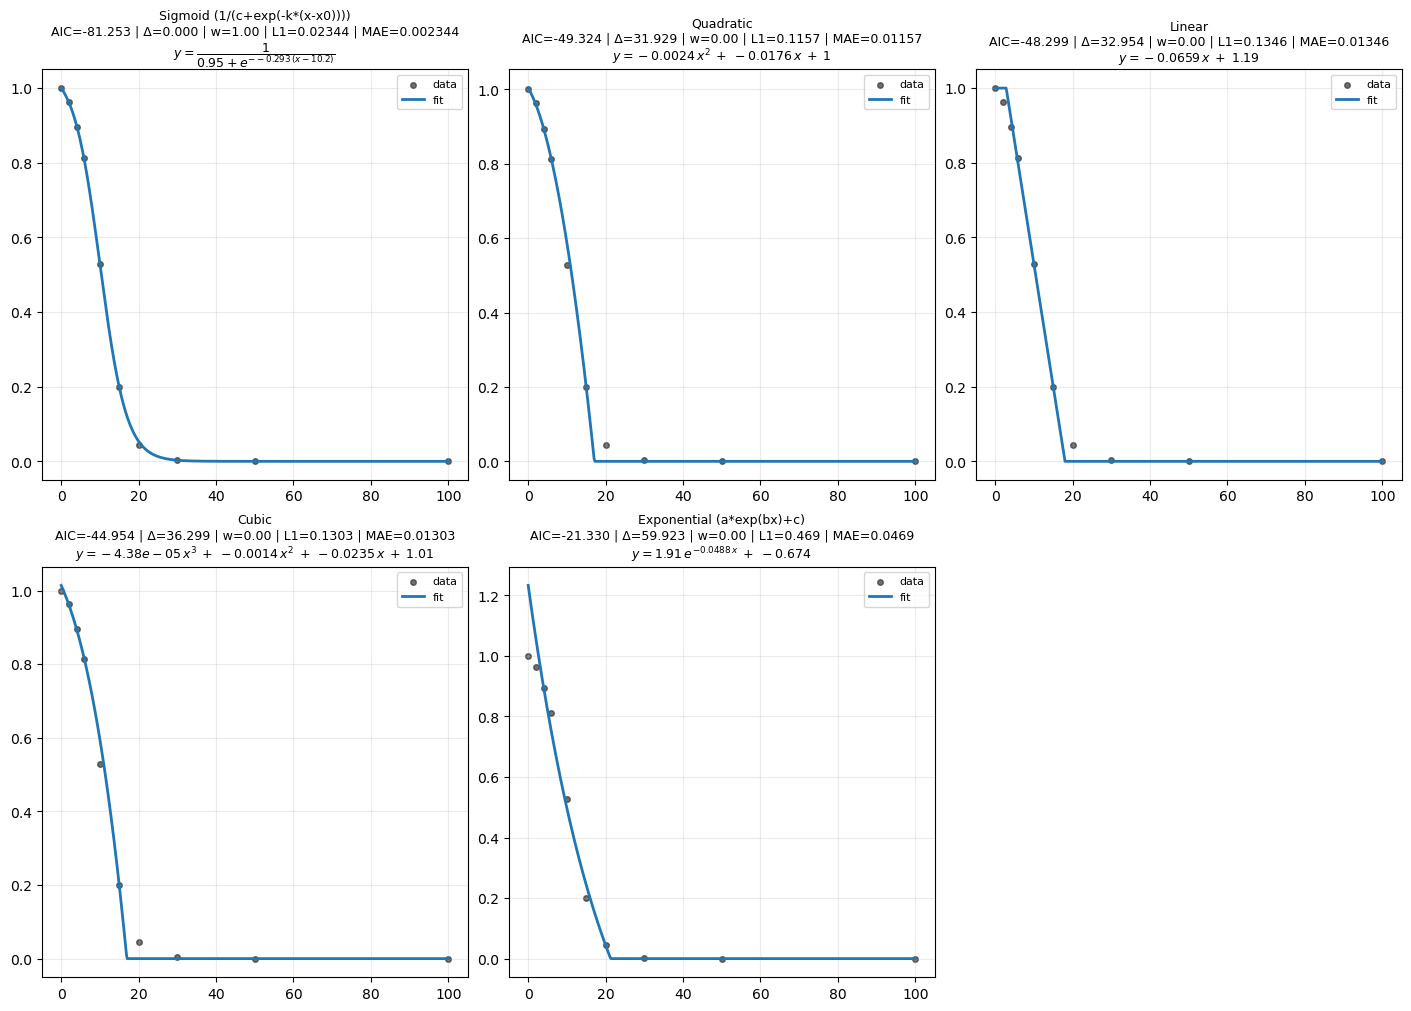

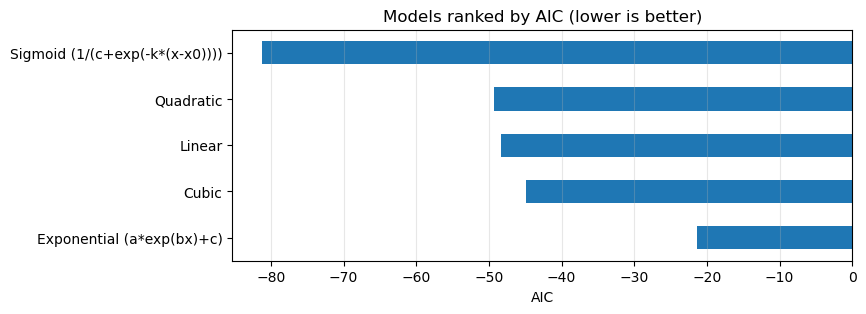

Best model by AIC: Sigmoid (1/(c+exp(-k*(x-x0))))
Parameters: [-0.293237 10.198399  0.949740]


In [5]:
### Fit data for random mismatches ###
yname = "Random"

m = (~df_mm[yname].isna())
x = df_mm[m]["Mismatches"]
y = df_mm[m][yname]
models_to_try = list(MODELS.keys())
summary_df, results = evaluate_and_plot(x, y, models_to_try=models_to_try)

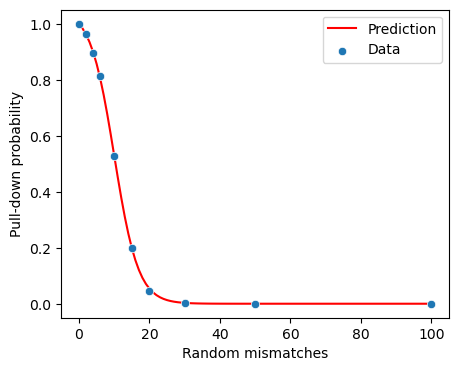

In [6]:
### Keep the sigmoid function ###
def random_mm(x, k=-0.293237, x0=10.198399, c=0.949740):
    pred = 1.0 / (c + np.exp(-k * (x - x0)))
    pred[pred > 1] = 1
    pred[pred < 0] = 0
    return(pred)


yname = "Random"
m = (~df_mm[yname].isna())
x = df_mm[m]["Mismatches"]
y = df_mm[m][yname]
x_pred = np.arange(0, 101)
y_pred = random_mm(x_pred)


fig, ax = plt.subplots(1, 1, figsize=(5, 4))
g1 = sns.lineplot(ax=ax, x=x_pred, y=y_pred, c="red", zorder=1, label="Prediction", errorbar=None)
g2 = sns.scatterplot(ax=ax, x=x, y=y, zorder=2, label="Data")
g1.set_xlabel("Random mismatches")
g1.set_ylabel("Pull-down probability");

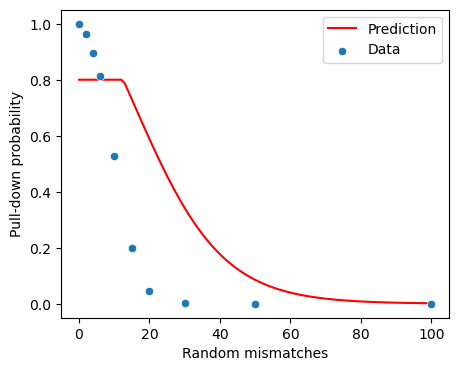

In [7]:
### Relaxed version ###
def random_mm(x, k=-0.08, x0=20, c=0.7, max=0.8):
    pred = 1.0 / (c + np.exp(-k * (x - x0)))
    pred[pred > max] = max
    pred[pred < 0] = 0
    return(pred)


yname = "Random"
m = (~df_mm[yname].isna())
x = df_mm[m]["Mismatches"]
y = df_mm[m][yname]
x_pred = np.arange(0, 101)
y_pred = random_mm(x_pred)


fig, ax = plt.subplots(1, 1, figsize=(5, 4))
g1 = sns.lineplot(ax=ax, x=x_pred, y=y_pred, c="red", zorder=1, label="Prediction", errorbar=None)
g2 = sns.scatterplot(ax=ax, x=x, y=y, zorder=2, label="Data")
g1.set_xlabel("Random mismatches")
g1.set_ylabel("Pull-down probability");

/var/folders/cl/x3bgk4d14dv2r6_19kf2m6180000gn/T/ipykernel_82415/2174067989.py:171: OptimizeWarning: Unknown solver options: xatol, fatol
  res = minimize(obj, p_start, method=method,
/var/folders/cl/x3bgk4d14dv2r6_19kf2m6180000gn/T/ipykernel_82415/2174067989.py:42: RuntimeWarning: overflow encountered in exp
  pred = 1.0 / (c + np.exp(-k * (x - x0)))


Skipping 'Power (a*x^b + c)' due to domain constraints.
Skipping 'Logarithmic (a*log(x)+b)' due to domain constraints.


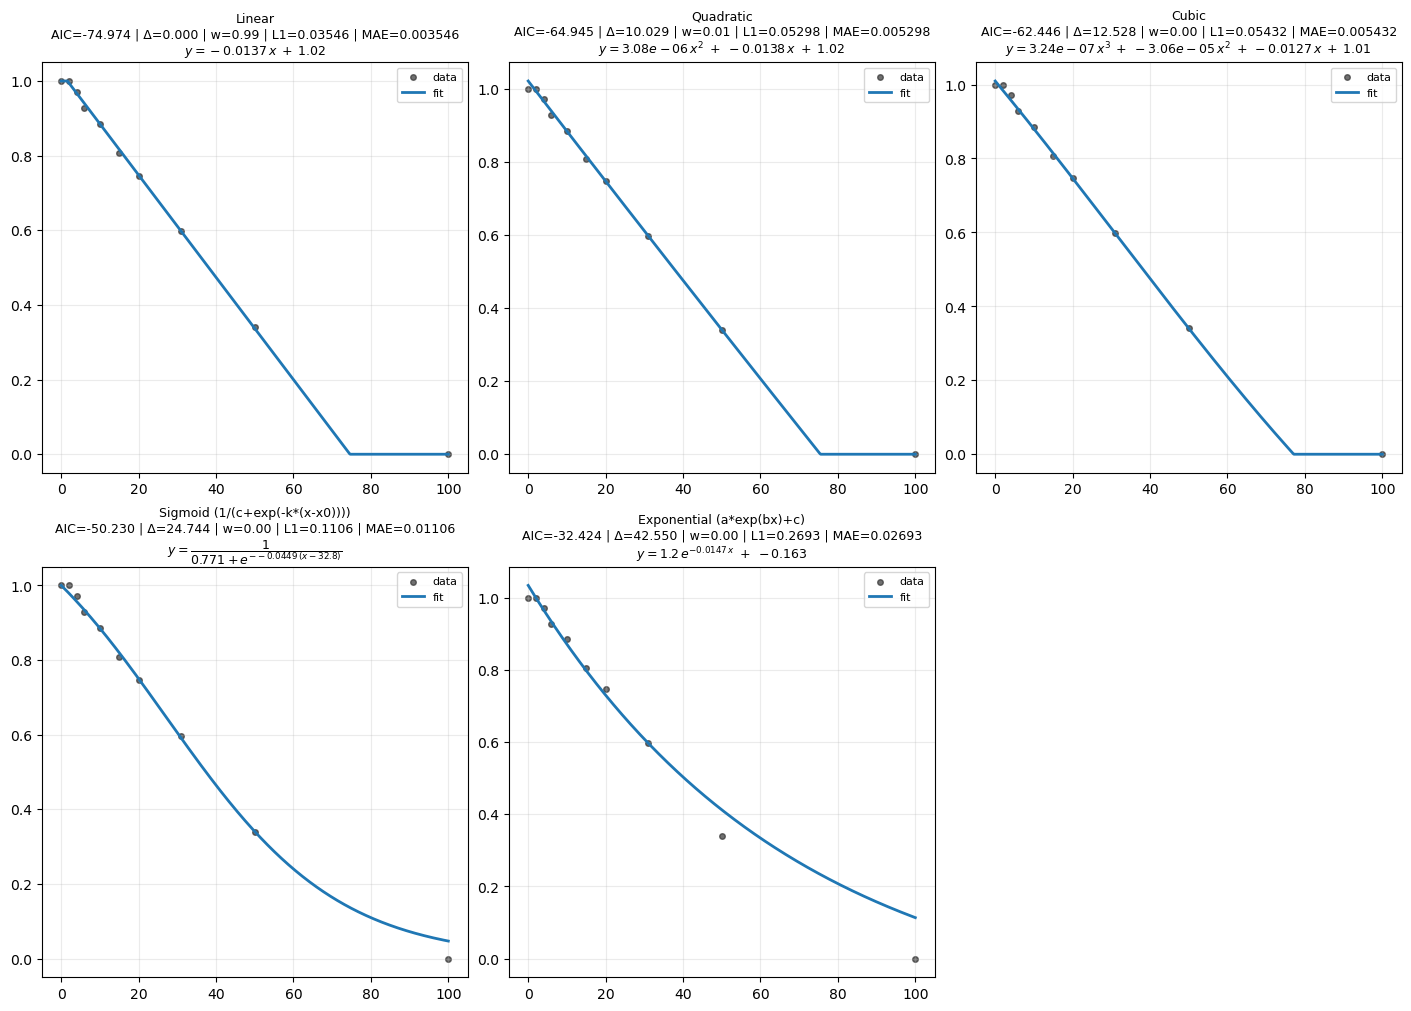

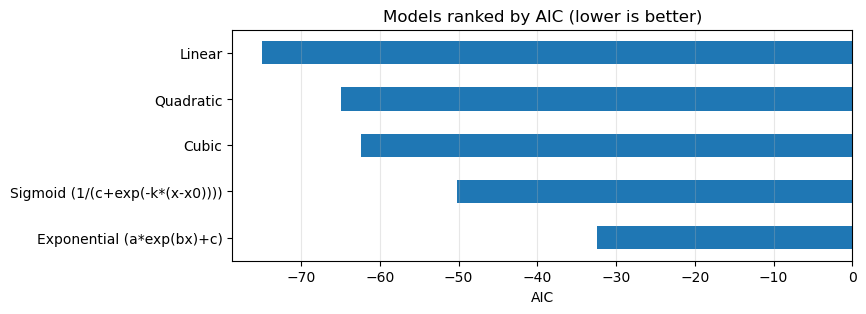

Best model by AIC: Linear
Parameters: [-0.013703  1.022119]


In [8]:
### Fit data for random mismatches ###
yname = "Contigious"

m = (~df_mm[yname].isna())
x = df_mm[m]["Mismatches"]
y = df_mm[m][yname]
models_to_try = list(MODELS.keys())
summary_df, results = evaluate_and_plot(x, y, models_to_try=models_to_try)

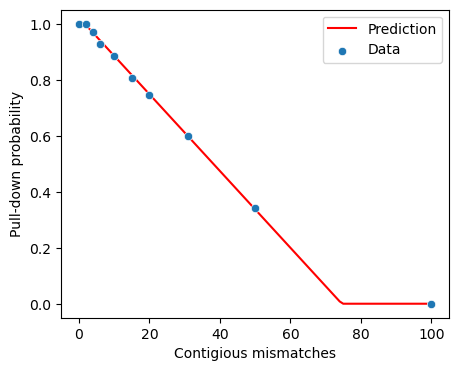

In [9]:
### Keep the linear function ###
def contigious_mm(x, a=-0.013703, b=1.022119):
    pred = a*x + b
    pred[pred < 0] = 0
    pred[pred > 1] = 1
    return(pred)

yname = "Contigious"
m = (~df_mm[yname].isna())
x = df_mm[m]["Mismatches"]
y = df_mm[m][yname]
x_pred = np.arange(0, 101)
y_pred = contigious_mm(x_pred)


fig, ax = plt.subplots(1, 1, figsize=(5, 4))
g1 = sns.lineplot(ax=ax, x=x_pred, y=y_pred, c="red", zorder=1, label="Prediction", errorbar=None)
g2 = sns.scatterplot(ax=ax, x=x, y=y, zorder=2, label="Data")
g1.set_xlabel("Contigious mismatches")
g1.set_ylabel("Pull-down probability");

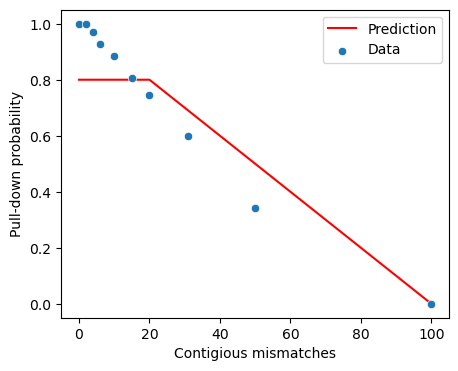

In [10]:
### Relaxed version ###
def contigious_mm(x, a=-0.01, b=1, max=0.8):
    pred = a*x + b
    pred[pred < 0] = 0
    pred[pred > max] = max
    return(pred)

yname = "Contigious"
m = (~df_mm[yname].isna())
x = df_mm[m]["Mismatches"]
y = df_mm[m][yname]
x_pred = np.arange(0, 101)
y_pred = contigious_mm(x_pred)


fig, ax = plt.subplots(1, 1, figsize=(5, 4))
g1 = sns.lineplot(ax=ax, x=x_pred, y=y_pred, c="red", zorder=1, label="Prediction", errorbar=None)
g2 = sns.scatterplot(ax=ax, x=x, y=y, zorder=2, label="Data")
g1.set_xlabel("Contigious mismatches")
g1.set_ylabel("Pull-down probability");